# Decision Tree using Titanic Data



In [1]:
import pandas as pd
import math
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import seaborn as sns

In [2]:
pip install graphviz --install-option="--include-path=C:\Users\musta\Downloads\Graphviz\include" --install-option="--library-path=C:\Users\musta\Downloads\Graphviz\lib"

Note: you may need to restart the kernel to use updated packages.


C:\Users\musta\anaconda3\lib\site-packages\pip\_internal\commands\install.py:229: UserWarning: Disabling all use of wheels due to the use of --build-option / --global-option / --install-option.
  cmdoptions.check_install_build_global(options)


In [3]:
from sklearn.tree import export_graphviz
import graphviz

In [4]:
tt = pd.read_csv(r"C:\Users\musta\Downloads\titanic.csv")

In [5]:
tt.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
# Four variables needed for the analysis were selected

In [7]:
tt_new = tt[['Survived','Pclass','Sex','Age','Fare']]

In [8]:
tt_new

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500
...,...,...,...,...,...
886,0,2,male,27.0,13.0000
887,1,1,female,19.0,30.0000
888,0,3,female,NaN,23.4500
889,1,1,male,26.0,30.0000


In [9]:
tt.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
#the Age variable has 177 null values, I converted the null to the mean of the ages.
tt_Age_avg = math.floor(tt_new.Age.mean())
tt_Age_avg

29

In [11]:
tt_new = tt_new.copy()
tt_new['Age'] = tt_new.Age.fillna(tt_Age_avg)

In [12]:
tt_new.isnull().sum() #checking to be sure the null values in age is filled with the average age.

Survived    0
Pclass      0
Sex         0
Age         0
Fare        0
dtype: int64

In [13]:
tt_new

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500
...,...,...,...,...,...
886,0,2,male,27.0,13.0000
887,1,1,female,19.0,30.0000
888,0,3,female,29.0,23.4500
889,1,1,male,26.0,30.0000


In [14]:
tt_new.dtypes

Survived      int64
Pclass        int64
Sex          object
Age         float64
Fare        float64
dtype: object

In [15]:
tt_new = tt_new.copy()
tt_new.loc[:, 'Age'] = tt_new['Age'].astype(int)

In [16]:
tt_new.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22,7.2500
1,1,1,female,38,71.2833
2,1,3,female,26,7.9250
3,1,1,female,35,53.1000
4,0,3,male,35,8.0500


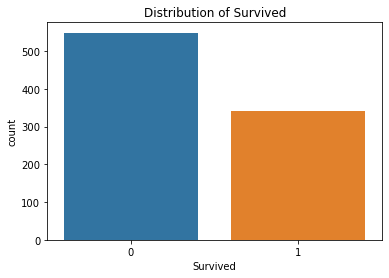

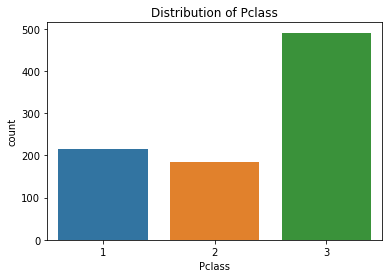

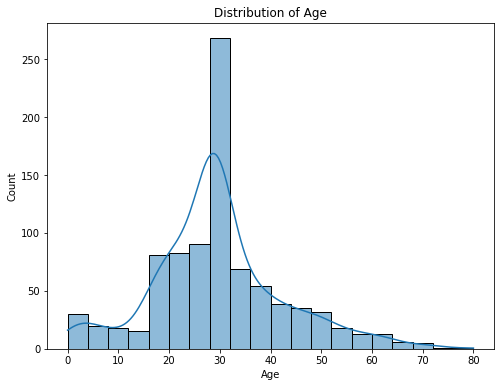

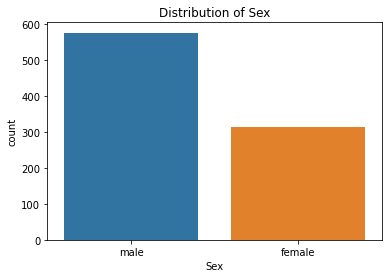

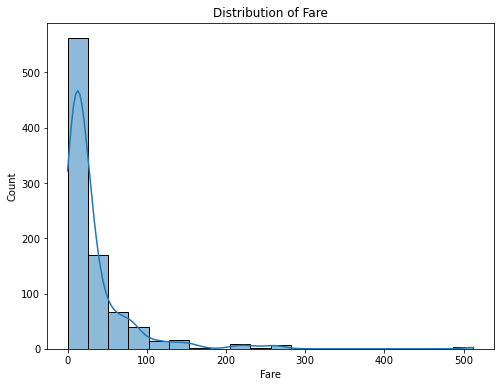

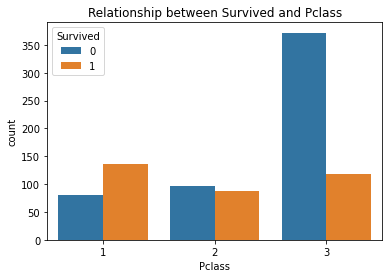

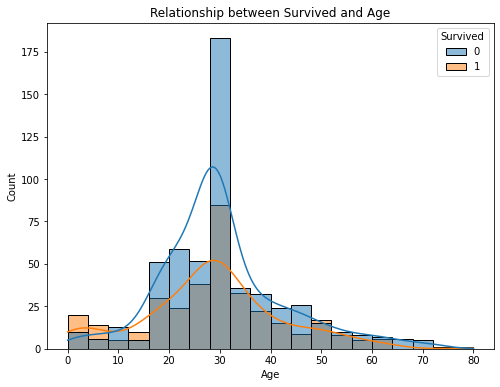

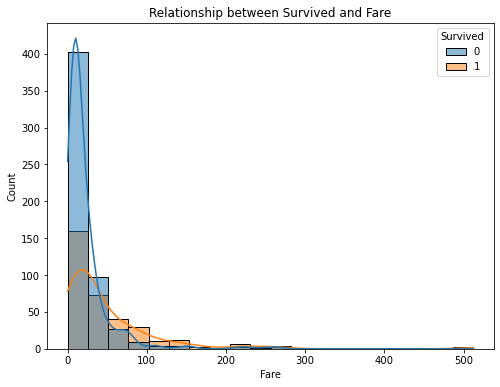

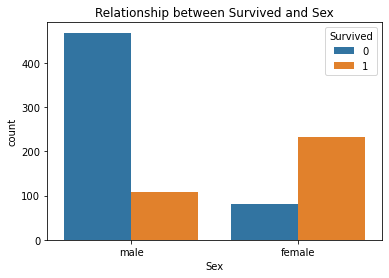

In [17]:

# Distribution of 'Survived' variable
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=tt_new)
plt.title('Distribution of Survived')
plt.show()

# Distribution of 'Pclass' variable
plt.figure(figsize=(6, 4))
sns.countplot(x='Pclass', data=tt_new)
plt.title('Distribution of Pclass')
plt.show()


# Distribution of 'Age' variable (excluding missing values)
plt.figure(figsize=(8, 6))
sns.histplot(tt_new['Age'].dropna(), bins=20, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.show()

# Distribution of 'Sex' variable
plt.figure(figsize=(6, 4))
sns.countplot(x='Sex', data=tt_new)
plt.title('Distribution of Sex')
plt.show()

# Distribution of 'Fare' variable
plt.figure(figsize=(8, 6))
sns.histplot(tt_new['Fare'], bins=20, kde=True)
plt.title('Distribution of Fare')
plt.xlabel('Fare')
plt.show()

# Relationship between 'Survived' and 'Pclass'
plt.figure(figsize=(6, 4))
sns.countplot(x='Pclass', hue='Survived', data=tt_new)
plt.title('Relationship between Survived and Pclass')
plt.show()


# Relationship between 'Survived' and 'Age' (excluding missing values)
plt.figure(figsize=(8, 6))
sns.histplot(x='Age', hue='Survived', data=tt_new, bins=20, kde=True)
plt.title('Relationship between Survived and Age')
plt.xlabel('Age')
plt.show()

# Relationship between 'Survived' and 'Fare'
plt.figure(figsize=(8, 6))
sns.histplot(x='Fare', hue='Survived', data=tt_new, bins=20, kde=True)
plt.title('Relationship between Survived and Fare')
plt.xlabel('Fare')
plt.show()

# Relationship between 'Survived' and 'Sex'
plt.figure(figsize=(6, 4))
sns.countplot(x='Sex', hue='Survived', data=tt_new)
plt.title('Relationship between Survived and Sex')
plt.show()

In [18]:
tt_new['Sex'] = tt_new['Sex'].map({'male': 0,'female' : 1}) # converting the categorical data(male, female) into numerical. A process known as encoding.

In [19]:
tt_new.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,0,22,7.2500
1,1,1,1,38,71.2833
2,1,3,1,26,7.9250
3,1,1,1,35,53.1000
4,0,3,0,35,8.0500


In [20]:
input_ = tt_new.drop('Survived', axis = 'columns')

In [21]:
target_ = tt_new.Survived

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
x_train,x_test,y_train,y_test = train_test_split(input_,target_,test_size = 0.2)

In [24]:
print(f'number of x_train :{len(x_train)} number of x_test :{len(x_test)}')

number of x_train :712 number of x_test :179


In [25]:
from sklearn import tree

In [26]:
model = tree.DecisionTreeClassifier()

In [27]:
model.fit(x_train,y_train)

DecisionTreeClassifier()

In [28]:
model.score(x_test,y_test)

0.7486033519553073

In [29]:
model.predict(x_test)

array([1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 0], dtype=int64)

In [30]:
model.predict([[3,1,27,45.00]])

array([0], dtype=int64)

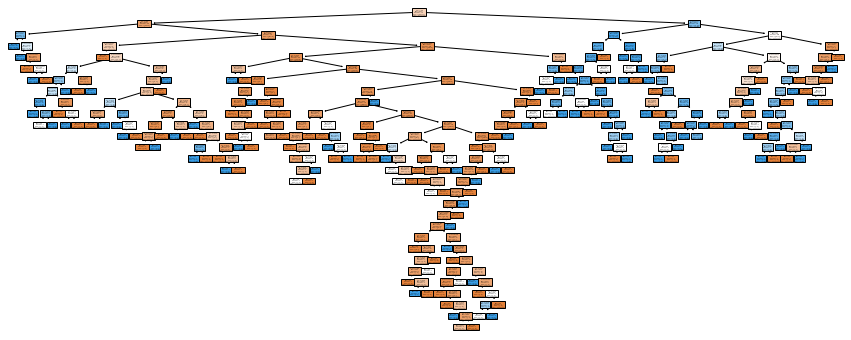

In [32]:
plt.figure(figsize=(15, 6))
plot_tree(model, feature_names=input_.columns, class_names=['Not Survived', 'Survived'], filled=True)
plt.show()

In [ ]:
# Downloading the tree map into a PDF for better visualization

import os
os.environ["PATH"] += os.pathsep + 'C:/Users/musta/Downloads/Graphviz/bin'

import graphviz
from sklearn.tree import export_graphviz

# Export the decision tree to a DOT file
dot_data = export_graphviz(model, out_file=None, feature_names=input_.columns, class_names=['Not Survived', 'Survived'], filled=True)

# Render the DOT file using Graphviz
graph = graphviz.Source(dot_data)

# Save the decision tree visualization as a PNG file
graph.render("decision_tree")

# Display the decision tree visualization
graph.view()